# 02: Propensity Modeling And IPW

The goal is to move from descriptive rank-position EDA to a first causal adjustment.

In notebook 1, we saw that items near the top have higher raw CTR. That raw gap needs adjustment because top-ranked items may differ from lower-ranked items in relevance, popularity, category, timing, or user context.

This notebook estimates a propensity model for top-3 exposure and uses inverse propensity weighting (IPW) to estimate an adjusted top-3 lift.

<!-- dataset-experiment-context -->
## Dataset and Design Context

This project uses the Microsoft News Dataset (MIND) impression logs. The working table is an impression-item panel: each row is one news item displayed inside a user impression slate.

The data come from a real observational ranking log. Top-3 exposure was created by a production ranker, so assignment must be treated as confounded. The treatment is top-3 exposure, the outcome is click-through, and the main causal risk is that the production ranker likely used relevance, freshness, and intent signals that remain only partly observed in the public data.

The project should therefore be read as an offline causal measurement and experiment-prioritization workflow. Naive rank-position click differences are descriptive. Adjusted estimates, overlap checks, heterogeneous effects, and policy simulations are used to decide what would be credible enough to test online.

**Role of this notebook.** This notebook models the probability of top-3 exposure from observed features and uses IPW to ask how much the naive ranking curve changes after observed adjustment.

<!-- mathematical-setup -->

## Mathematical Setup

This notebook introduces the propensity score, the probability that an item-impression receives top placement after conditioning on observed features \(X_i\):

$$
e(X_i)=\Pr(T_i=1\mid X_i).
$$

If the observed features are rich enough for conditional exchangeability, the top-rank average treatment effect can be written as

$$
\tau = \mathbb{E}\left[Y_i(1)-Y_i(0)\right].
$$

Inverse-probability weighting creates a pseudo-population where observed covariates are less imbalanced across treatment groups. The stabilized IPW estimate used in this notebook has the form

$$
\widehat{\tau}_{\text{IPW}}=
\frac{1}{n}\sum_{i=1}^n
\left(\frac{T_iY_i}{\widehat e(X_i)}-
\frac{(1-T_i)Y_i}{1-\widehat e(X_i)}\right).
$$

The overlap diagnostics are as important as the estimate. If \(\widehat e(X_i)\) is very close to 0 or 1, the corresponding weight becomes large and the adjusted estimate can be driven by a small number of observations.


## Causal Setup

We start with a binary treatment because it is easier to explain and diagnose than exact rank position.

- **Treatment**: `is_top_3 = 1`, meaning the item appeared in rank positions 1, 2, or 3.
- **Control**: `is_top_3 = 0`, meaning the item appeared below rank 3.
- **Outcome**: `clicked`, meaning whether the user clicked the displayed item.
- **Covariates**: observed user, item, and context features measured in the processed table.

The core idea is to estimate:

`P(is_top_3 = 1 | observed covariates)`

This probability is called the **propensity score**. If two rows have similar propensity scores but one was top-3 and the other was lower-ranked, they are more comparable than arbitrary treated/control rows.

IPW then gives more weight to observations that were unlikely to receive the treatment they actually received. This tries to create a pseudo-population where observed covariates are more balanced between top-3 and lower-ranked items.

#### Setup

This cell imports the libraries needed for propensity modeling and IPW. `pandas` and `numpy` handle the data, `matplotlib` and `seaborn` make diagnostic plots, and scikit-learn provides preprocessing, train/test splitting, metrics, and logistic regression for the propensity model.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)


This cell prepares the notebook environment for propensity-score overlap and inverse-probability weighting. There is no substantive model result yet; the important outcome is that the imports and display settings are ready so the next cells can focus on the data and causal question.


#### Load The Processed MIND Table

This cell locates the project root, reads the processed parquet file, and loads it into `df`. The same path logic lets the notebook run from the repository root or from the `notebooks/` directory. The output shape confirms how many displayed-item rows and columns are available.

In [2]:
DATA_RELATIVE_PATH = Path("data/processed/mind_small_impressions_train_sample.parquet")
PROJECT_ROOT = next(
    path
    for path in [Path.cwd(), *Path.cwd().parents]
    if (path / DATA_RELATIVE_PATH).exists()
)

DATA_PATH = PROJECT_ROOT / DATA_RELATIVE_PATH
df = pd.read_parquet(DATA_PATH)

df.shape


(737762, 20)

The loaded table preview and shape confirm that the notebook is using the expected processed dataset. This check anchors the rest of the analysis, because all treatment, outcome, and covariate definitions depend on these columns being present and correctly typed.


### Modeling Sample

The processed file has hundreds of thousands of displayed-item rows. That is small enough for analysis, but using a moderate sample keeps the notebook responsive while we are still developing the methodology.

`MODEL_SAMPLE_SIZE = 250_000` means we randomly sample up to 250,000 rows for this first IPW pass. Later, once the workflow is stable, we can run the same code on the full processed table or a larger MIND extract.

#### Create The Modeling Sample

This cell samples up to 250,000 rows to keep the notebook responsive. It creates explicit `treatment` and `outcome` columns from `is_top_3` and `clicked`, adds a log-transformed exposure feature, and creates a readable treatment label for plots. The final describe table checks the basic scale of treatment, outcome, and rank position in the modeling sample.

In [3]:
MODEL_SAMPLE_SIZE = 250_000
RANDOM_STATE = 42

model_df = df.sample(n=min(len(df), MODEL_SAMPLE_SIZE), random_state=RANDOM_STATE).copy()
model_df["treatment"] = model_df["is_top_3"].astype(int)
model_df["outcome"] = model_df["clicked"].astype(int)
model_df["log_item_exposures"] = np.log1p(model_df["item_exposures"])
model_df["treatment_label"] = np.where(model_df["treatment"] == 1, "top_3", "rank_4_plus")

model_df[["treatment", "outcome", "rank_position"]].describe()


,treatment,outcome,rank_position
count,250000.0000,250000.0000,250000.0000
mean,0.0797,0.0400,38.7896
std,0.2708,0.1961,37.5720
min,0.0000,0.0000,1.0000
25%,0.0000,0.0000,11.0000
50%,0.0000,0.0000,27.0000
75%,0.0000,0.0000,55.0000
max,1.0000,1.0000,293.0000


This cell defines the working analysis sample and standardizes treatment/outcome columns. Fixing this sample early keeps later model comparisons fair because each estimator works on the same rows and target definition.


### Feature Set for the Propensity Model

The propensity model should predict treatment assignment. So the target is `treatment`.

We include features that describe the user, item, and context:

- `history_len`: user activity/history size.
- `candidate_set_size`: number of items displayed in the same impression.
- `title_length`, `abstract_length`: simple content-text proxies.
- `hour`, `day_of_week`: timing context.
- `log_item_exposures`: exposure/popularity proxy, log-transformed because raw exposure counts are skewed.
- `category`, `subcategory`: content metadata.

We intentionally exclude `clicked`, `item_clicks`, and `item_ctr` from this propensity model. Those are outcome-based features. Including them can leak click behavior into the treatment model and make the causal story harder to defend. In a production version, item popularity should be computed from information available before the impression, such as rolling historical exposure/click counts.

#### Define Model Inputs

This cell declares the covariates used to predict treatment assignment. Numeric and categorical features are listed separately because they need different preprocessing. Then the notebook builds `X` for covariates, `t` for treatment, and `y` for outcome. The small summary checks treatment prevalence and overall click rate before fitting any model.

In [4]:
numeric_features = [
    "history_len",
    "candidate_set_size",
    "title_length",
    "abstract_length",
    "hour",
    "day_of_week",
    "log_item_exposures",
]
categorical_features = ["category", "subcategory"]

feature_cols = numeric_features + categorical_features

X = model_df[feature_cols]
t = model_df["treatment"]
y = model_df["outcome"]

pd.Series(
    {
        "rows": len(model_df),
        "treatment_rate_top_3": t.mean(),
        "outcome_rate_clicked": y.mean(),
    }
)


rows                   250000.0000
treatment_rate_top_3        0.0797
outcome_rate_clicked        0.0400
dtype: float64

The feature lists define what information is allowed into the adjustment models. These are pre-treatment or contextual variables intended to reduce confounding without using the outcome itself as an input.


#### Fit A Propensity Model

This cell fits a logistic regression model to estimate the probability that each displayed item appears in the top 3, conditional on observed covariates.

The preprocessing does two things:

- Numeric features are median-imputed and standardized.
- Categorical features are imputed and one-hot encoded.

The model is evaluated on a held-out split. The metrics help us understand whether observed features carry information about treatment assignment.

- **ROC AUC**: ranking quality for treated versus control rows.
- **Average precision**: useful when treatment is imbalanced.
- **Brier score**: probability calibration error; lower is better.

A very predictive propensity model means top-3 assignment is highly structured by observed features. This predictability makes raw treated/control comparisons risky.

#### Train And Evaluate The Propensity Model

This cell splits the data into train and test sets, preprocesses numeric and categorical features, fits logistic regression, and evaluates predicted propensities on held-out rows. The model predicts top-3 assignment. The metrics tell us how much observed covariates explain treatment assignment.

In [5]:
# Train and evaluate the propensity model.
X_train, X_test, t_train, t_test = train_test_split(
    X,
    t,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=t,
)

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="infrequent_if_exist",
                min_frequency=50,
                sparse_output=True,
            ),
        ),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ]
)

propensity_model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        (
            "model",
            LogisticRegression(
                max_iter=500,
                solver="lbfgs",
                n_jobs=-1,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

propensity_model.fit(X_train, t_train)

test_propensity = propensity_model.predict_proba(X_test)[:, 1]
pd.Series(
    {
        "roc_auc": roc_auc_score(t_test, test_propensity),
        "average_precision": average_precision_score(t_test, test_propensity),
        "brier_score": brier_score_loss(t_test, test_propensity),
    }
)


roc_auc             0.7697
average_precision   0.3235
brier_score         0.0660
dtype: float64

The propensity-model metrics show how predictable top-3 exposure is from observed covariates. Strong predictability points to selection bias, and calibrated probabilities are needed for stable weighting.


### Overlap Diagnostics

IPW depends on **overlap**, also called **positivity**.

Overlap means that, for the covariate profiles we observe, there is some chance of being top-3 and some chance of being lower-ranked. If a row has propensity nearly 0 or nearly 1, then there are few comparable observations in the opposite group.

The next cells add predicted propensities to the modeling sample and compare their distributions for treated and control rows. Good overlap means the two distributions share meaningful common support. Poor overlap means IPW estimates can become unstable because a few observations receive huge weights.

#### Add Propensity Scores To Each Row

This cell scores every row in the modeling sample with the fitted propensity model. The resulting `propensity` value is the estimated probability that the row appears in the top 3 given its observed covariates. The grouped summary compares propensity distributions for treated and control rows.

In [6]:
model_df["propensity"] = propensity_model.predict_proba(X)[:, 1]

model_df.groupby("treatment_label")["propensity"].describe(
    percentiles=[0.01, 0.05, 0.10, 0.50, 0.90, 0.95, 0.99]
)


,count,mean,std,min,1%,5%,10%,50%,90%,95%,99%,max
treatment_label,,,,,,,,,,,,
rank_4_plus,230074.0000,0.0727,0.0668,0.0001,0.0004,0.0027,0.0069,0.0513,0.1732,0.2083,0.2633,0.3928
top_3,19926.0000,0.1602,0.0922,0.0002,0.0036,0.0140,0.0287,0.1611,0.2840,0.3037,0.3302,0.4060


The added propensity scores estimate each row's probability of receiving the treatment given observed features. These scores are the bridge from descriptive imbalance to inverse-probability adjustment.


#### Plot Propensity Overlap

This cell plots the propensity score distributions for top-3 and lower-ranked rows. Meaningful overlap is important because IPW needs comparable treated and control observations. If the two distributions barely overlap, the adjusted estimate will rely heavily on extrapolation and unstable weights.

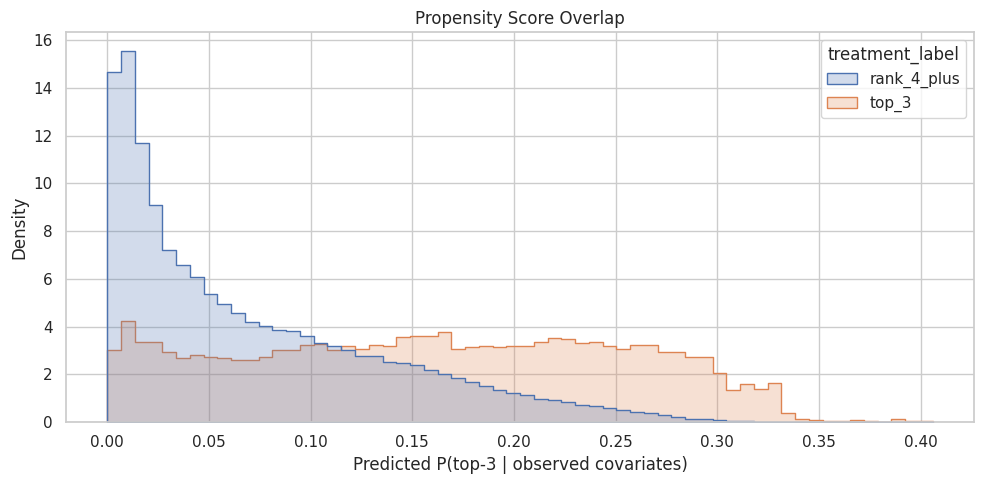

In [7]:
plt.figure(figsize=(10, 5))
sns.histplot(
    data=model_df,
    x="propensity",
    hue="treatment_label",
    bins=60,
    stat="density",
    common_norm=False,
    element="step",
)
plt.title("Propensity Score Overlap")
plt.xlabel("Predicted P(top-3 | observed covariates)")
plt.ylabel("Density")
plt.tight_layout()


The overlap plot shows whether treated and control rows share comparable propensity-score ranges. Good overlap supports weighting; poor overlap warns that some treated rows have no credible comparison rows, or vice versa.


#### Build IPW Weights

For each row, IPW uses the inverse probability of receiving the treatment actually observed:

- Treated row weight: `1 / propensity`.
- Control row weight: `1 / (1 - propensity)`.

A treated row with low predicted probability of being top-3 gets a large weight because it represents other similar rows that usually appear outside the top 3. A control row with high predicted probability of being top-3 also gets a large weight.

Large weights can make estimates unstable, so this notebook clips propensities away from 0 and 1, then caps IPW weights at the 99th percentile. This is a practical first-pass stabilization. In a final analysis, we would report sensitivity to different clipping/capping choices.

#### Calculate And Stabilize IPW Weights

This cell creates inverse propensity weights. Treated rows get weight `1 / propensity`, and control rows get weight `1 / (1 - propensity)`. The propensities are clipped away from 0 and 1 to avoid infinite or extreme weights, and the final weights are capped at the 99th percentile for a stable first-pass estimate.

In [8]:
EPS = 0.01
model_df["propensity_clipped"] = model_df["propensity"].clip(EPS, 1 - EPS)
model_df["ipw"] = np.where(
    model_df["treatment"] == 1,
    1 / model_df["propensity_clipped"],
    1 / (1 - model_df["propensity_clipped"]),
)

weight_cap = model_df["ipw"].quantile(0.99)
model_df["ipw_capped"] = model_df["ipw"].clip(upper=weight_cap)

pd.Series(
    {
        "propensity_clip_epsilon": EPS,
        "weight_cap_99th_percentile": weight_cap,
        "max_uncapped_weight": model_df["ipw"].max(),
        "max_capped_weight": model_df["ipw_capped"].max(),
    }
)


propensity_clip_epsilon        0.0100
weight_cap_99th_percentile    26.2346
max_uncapped_weight          100.0000
max_capped_weight             26.2346
dtype: float64

The weight calculation translates propensity scores into reweighting factors for the observed data. Stabilization and clipping protect the estimate from a few extreme-propensity rows dominating the result.


#### Inspect Weight Distributions

This cell summarizes uncapped and capped IPW weights separately for top-3 and lower-ranked rows. It helps identify whether one group has much larger weights, whether capping changed the tail, and whether a small number of rows might dominate the weighted estimate.

In [9]:
model_df.groupby("treatment_label")[["ipw", "ipw_capped"]].describe(
    percentiles=[0.50, 0.90, 0.95, 0.99]
)


ipw                                                \
                      count    mean     std    min    50%     90%     95%   
treatment_label                                                             
rank_4_plus     230074.0000  1.0854  0.0849 1.0101 1.0541  1.2095  1.2632   
top_3            19926.0000 14.4013 21.5737 2.4633 6.2091 34.8184 71.5165   

                                   ipw_capped                              \
                     99%      max       count   mean    std    min    50%   
treatment_label                                                             
rank_4_plus       1.3573   1.6468 230074.0000 1.0854 0.0849 1.0101 1.0541   
top_3           100.0000 100.0000  19926.0000 9.7144 7.6900 2.4633 6.2091   

                                                 
                    90%     95%     99%     max  
treatment_label                                  
rank_4_plus      1.2095  1.2632  1.3573  1.6468  
top_3           26.2346 26.2346 26.2346 26.2346

The weight summary and plot show whether the reweighted analysis is numerically stable. Highly concentrated weights would make the adjusted estimate noisy and fragile.


#### Plot Capped Weight Distribution

This cell visualizes the capped IPW weights. A healthy first-pass weighting scheme should avoid domination by a very long tail of extreme weights. If the chart shows many large weights, we may need stronger clipping, a different treatment definition, or better overlap restrictions.

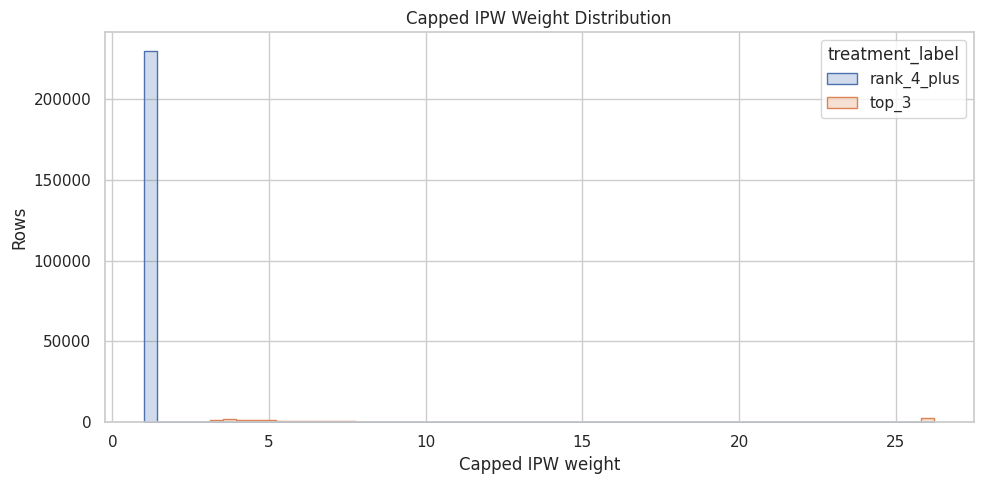

In [10]:
plt.figure(figsize=(10, 5))
sns.histplot(data=model_df, x="ipw_capped", hue="treatment_label", bins=60, element="step")
plt.title("Capped IPW Weight Distribution")
plt.xlabel("Capped IPW weight")
plt.ylabel("Rows")
plt.tight_layout()


The weight summary and plot show whether the reweighted analysis is numerically stable. Highly concentrated weights would make the adjusted estimate noisy and fragile.


### Balance Before and After Weighting

A useful diagnostic is whether weighting makes treated and control rows more similar on observed covariates.

For numeric features, we calculate the **standardized mean difference** (SMD):

`SMD = (treated mean - control mean) / pooled standard deviation`

Rules of thumb vary, but absolute SMD below about `0.1` is often considered reasonably balanced. Here we compare SMD before weighting and after IPW weighting. If IPW is doing its job, the absolute SMDs should usually move closer to zero.

#### Compute Numeric Balance Diagnostics

This cell defines helper functions for weighted means, weighted variances, and standardized mean differences. It then calculates balance before weighting and after IPW for each numeric feature. The output shows whether weighting moves treated and control rows closer together on observed covariates.

In [11]:
# Compute numeric balance diagnostics.
def weighted_mean(values, weights):
    """
    Compute a weighted mean for causal diagnostics.
    
    Idea
    ----
    Use this helper when treated-control averages, covariate summaries, or estimator components need to respect inverse-propensity or stabilized weights.
    
    Parameters
    ----------
    values : object
        Numeric values to summarize.
    weights : object
        Observation weights aligned with the values.
    
    Returns
    -------
    float
        Weighted average after aligning values and weights and ignoring missing pairs.
    """
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    return np.sum(values * weights) / np.sum(weights)


def weighted_var(values, weights):
    """
    Compute a weighted variance for balance and uncertainty diagnostics.
    
    Idea
    ----
    The calculation supports weighted standardized mean differences by measuring spread under the same weighting scheme used for adjustment.
    
    Parameters
    ----------
    values : object
        Numeric values to summarize.
    weights : object
        Observation weights aligned with the values.
    
    Returns
    -------
    float
        Weighted variance of the non-missing values.
    """
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    mean = weighted_mean(values, weights)
    return np.sum(weights * (values - mean) ** 2) / np.sum(weights)


def numeric_smd(data, feature, treatment_col="treatment", weight_col=None):
    """
    Compute a standardized mean difference for one numeric MIND covariate.
    
    Idea
    ----
    The function compares treated and control rows, optionally after weighting, so rank-position imbalance can be audited before interpreting causal estimates.
    
    Parameters
    ----------
    data : object
        Input analysis table for the current project step.
    feature : object
        Name of the covariate or feature to summarize.
    treatment_col : object
        Column indicating treatment or exposure status.
    weight_col : object
        Column containing observation weights.
    
    Returns
    -------
    float
        Standardized mean difference for the requested feature.
    """
    treated = data[treatment_col] == 1
    control = ~treated
    x_t = data.loc[treated, feature]
    x_c = data.loc[control, feature]

    if weight_col is None:
        mean_t = x_t.mean()
        mean_c = x_c.mean()
        var_t = x_t.var(ddof=0)
        var_c = x_c.var(ddof=0)
    else:
        w_t = data.loc[treated, weight_col]
        w_c = data.loc[control, weight_col]
        mean_t = weighted_mean(x_t, w_t)
        mean_c = weighted_mean(x_c, w_c)
        var_t = weighted_var(x_t, w_t)
        var_c = weighted_var(x_c, w_c)

    pooled_sd = np.sqrt((var_t + var_c) / 2)
    return (mean_t - mean_c) / pooled_sd if pooled_sd > 0 else np.nan


balance_rows = []
for feature in numeric_features:
    balance_rows.append(
        {
            "feature": feature,
            "smd_before": numeric_smd(model_df, feature),
            "smd_after_ipw": numeric_smd(model_df, feature, weight_col="ipw_capped"),
        }
    )

balance_df = pd.DataFrame(balance_rows)
balance_df["abs_smd_before"] = balance_df["smd_before"].abs()
balance_df["abs_smd_after_ipw"] = balance_df["smd_after_ipw"].abs()
balance_df.sort_values("abs_smd_before", ascending=False)


,feature,smd_before,smd_after_ipw,abs_smd_before,abs_smd_after_ipw
1,candidate_set_size,-0.9231,-0.2236,0.9231,0.2236
6,log_item_exposures,0.3263,0.0407,0.3263,0.0407
0,history_len,-0.0686,0.0025,0.0686,0.0025
2,title_length,0.0415,-0.0056,0.0415,0.0056
5,day_of_week,-0.0321,0.0004,0.0321,0.0004
4,hour,0.0225,0.0115,0.0225,0.0115
3,abstract_length,-0.0045,0.0101,0.0045,0.0101


The balance diagnostics show whether weighting moves treated and control covariate distributions closer together. Improved balance is a sanity check that the adjustment is doing the job it was designed to do.


#### Plot Balance Improvement

This cell turns the balance table into a bar chart. For each numeric feature, it compares absolute standardized mean difference before weighting and after IPW. The dashed vertical line at `0.1` is a common rough threshold for acceptable balance.

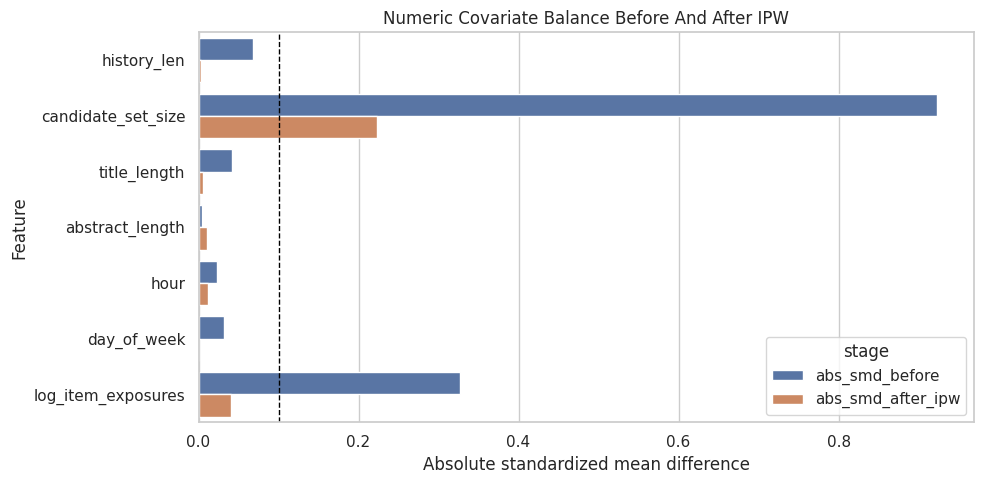

In [12]:
plot_df = balance_df.melt(
    id_vars="feature",
    value_vars=["abs_smd_before", "abs_smd_after_ipw"],
    var_name="stage",
    value_name="abs_smd",
)

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x="abs_smd", y="feature", hue="stage")
plt.axvline(0.1, color="black", linestyle="--", linewidth=1)
plt.title("Numeric Covariate Balance Before And After IPW")
plt.xlabel("Absolute standardized mean difference")
plt.ylabel("Feature")
plt.tight_layout()


The balance diagnostics show whether weighting moves treated and control covariate distributions closer together. Improved balance is a sanity check that the adjustment is doing the job it was designed to do.


### Estimate Adjusted Top-3 Lift

Now we compare the naive top-3 lift with the IPW-adjusted lift.

- **Naive top-3 CTR**: average click rate among top-3 rows.
- **Naive lower-ranked CTR**: average click rate among lower-ranked rows.
- **Naive lift**: raw difference between those two CTRs.
- **IPW top-3 CTR**: weighted click rate among top-3 rows, using inverse propensity weights.
- **IPW lower-ranked CTR**: weighted click rate among lower-ranked rows.
- **IPW lift**: adjusted difference between weighted CTRs.

If IPW lift is smaller than naive lift, that suggests some of the raw top-3 advantage was due to observed confounding. If IPW lift remains large, that is evidence consistent with a real position effect, subject to the assumptions of no unobserved confounding, overlap, and correct-enough model specification.

#### Estimate Naive And IPW-Adjusted Lift

This cell computes click-through rates for top-3 and lower-ranked rows in two ways: unweighted naive averages and IPW-weighted averages. The difference between those rates is the estimated lift. Comparing the naive and IPW rows tells us how much observed confounding changes the apparent top-3 advantage.

In [13]:
# Estimate naive and IPW-adjusted lift.
def group_weighted_mean(data, group_value, outcome_col="outcome", weight_col="ipw_capped"):
    """
    Compute a group-specific weighted outcome mean.
    
    Idea
    ----
    This helper compares adjusted outcomes inside treatment groups, segments, or exposure groups while using the same weights as the causal estimator.
    
    Parameters
    ----------
    data : object
        Input analysis table for the current project step.
    group_value : object
        Project-specific input named `group_value` used by this helper.
    outcome_col : object
        Outcome column used in the estimator.
    weight_col : object
        Column containing observation weights.
    
    Returns
    -------
    float
        Weighted mean outcome for the selected group.
    """
    mask = data["treatment"] == group_value
    return weighted_mean(data.loc[mask, outcome_col], data.loc[mask, weight_col])


naive_top3_ctr = model_df.loc[model_df["treatment"] == 1, "outcome"].mean()
naive_lower_ctr = model_df.loc[model_df["treatment"] == 0, "outcome"].mean()
ipw_top3_ctr = group_weighted_mean(model_df, 1)
ipw_lower_ctr = group_weighted_mean(model_df, 0)

estimate_table = pd.DataFrame(
    [
        {
            "method": "naive",
            "top3_ctr": naive_top3_ctr,
            "lower_rank_ctr": naive_lower_ctr,
            "absolute_lift": naive_top3_ctr - naive_lower_ctr,
            "relative_lift": naive_top3_ctr / naive_lower_ctr - 1,
        },
        {
            "method": "ipw_capped",
            "top3_ctr": ipw_top3_ctr,
            "lower_rank_ctr": ipw_lower_ctr,
            "absolute_lift": ipw_top3_ctr - ipw_lower_ctr,
            "relative_lift": ipw_top3_ctr / ipw_lower_ctr - 1,
        },
    ]
)

estimate_table


,method,top3_ctr,lower_rank_ctr,absolute_lift,relative_lift
0,naive,0.1017,0.0347,0.0670,1.9311
1,ipw_capped,0.0558,0.0364,0.0194,0.5320


This output is part of the propensity-score overlap and inverse-probability weighting workflow. Read it as a checkpoint: it either verifies an input, defines reusable analysis machinery, or produces a diagnostic that motivates the next step in the notebook.


### Effective Sample Size

This cell computes the effective sample size after weighting. IPW can make a large dataset behave like a smaller one when a few rows receive large weights. Effective sample size is a useful stability diagnostic: lower values mean the weighted estimate has less independent information than the raw row count suggests.

In [14]:
def effective_sample_size(weights):
    """
    Compute the effective sample size implied by importance weights.
    
    Idea
    ----
    Large or unstable weights can make an estimator behave as if it had far fewer observations; this diagnostic turns weight concentration into a readable sample-size number.
    
    Parameters
    ----------
    weights : object
        Observation weights aligned with the values.
    
    Returns
    -------
    float
        Effective sample size computed as squared total weight divided by total squared weight.
    """
    weights = np.asarray(weights, dtype=float)
    return weights.sum() ** 2 / np.sum(weights**2)


ess = (
    model_df.groupby("treatment_label")["ipw_capped"]
    .apply(effective_sample_size)
    .rename("effective_sample_size")
)
ess


treatment_label
rank_4_plus   228674.8828
top_3          12249.9217
Name: effective_sample_size, dtype: float64

Effective sample size translates the weight distribution into a practical precision warning. A large drop from raw sample size means the estimator is relying on fewer weighted observations than the row count suggests.


## Interpretation Checklist

Use this checklist when reading the results:

1. Did the propensity model find structure in top-3 assignment?
2. Do treated and control rows have reasonable propensity overlap?
3. Are IPW weights stable, or are a few rows dominating the estimate?
4. Did numeric covariate balance improve after weighting?
5. How different is IPW lift from naive lift?

This notebook gives the first adjusted estimate. The next step is a doubly robust estimator, which combines a propensity model with an outcome model to reduce dependence on a single modeling approach.